# Inverse PSD Calibration Without IQ

This notebook implements a monotone statistical inverse mapping from node PSD (dB) to reference PSD (`Node7-Bogota`) with:
- Layer A: hard-distortion row filtering (MAD/percentile thresholds).
- Layer B: per-row global offset estimation used as AGC/state normalization.
- Layer C: level-dependent states via quantile bins.
- Core inverse: per-state monotone isotonic mapping per frequency (anchor fitting + deterministic frequency regularization).
- Train/test block split evaluation to avoid leakage.
- NPZ export/import with piecewise-linear breakpoints (`x_knots`, `y_knots`).


In [3]:
from __future__ import annotations

import ast
import glob
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd


# -----------------------
# Configuration
# -----------------------
DATA_GLOB = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"
REFERENCE_NODE = "Node7-Bogota"
PXX_COLUMN = "pxx"
ROI_MHZ = (97.0, 99.0)

TRAIN_FRACTION = 0.70
LEVEL_BINS = 6

# Layer A (hard-distortion filtering) defaults.
ROI_FLOOR_PERCENTILE = 10.0
ROI_SPREAD_LOW_PERCENTILE = 10.0
ROI_SPREAD_HIGH_PERCENTILE = 90.0
THRESHOLD_LOW_PERCENTILE = 5.0
THRESHOLD_HIGH_PERCENTILE = 95.0
THRESHOLD_MAD_SCALE = 3.5
MIN_VALID_ROI_BINS = 16

# Baseline H(f) smoothing.
H_SMOOTHING_BINS = 129

# Inverse mapping defaults.
INVERSE_FREQ_STRIDE = 16
INVERSE_X_KNOTS = 21
INVERSE_FREQ_SMOOTH_BINS = 9
MIN_POINTS_PER_ISOTONIC = 10
MAX_QUANTILE_SAMPLES = 200_000


def parse_pxx_cell(
    pxx_raw: object,  # Raw CSV cell containing one PSD vector
) -> np.ndarray:      # Parsed PSD vector in dB [n_bins]
    '''Parses one CSV PSD cell into a 1D float vector.'''
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float).ravel()

    if isinstance(pxx_raw, list):
        return np.asarray(pxx_raw, dtype=float).ravel()

    text = str(pxx_raw).strip()
    if text.startswith("[") and text.endswith("]"):
        vector = np.fromstring(text[1:-1], sep=",", dtype=float)
    else:
        vector = np.asarray(ast.literal_eval(text), dtype=float)
    return np.asarray(vector, dtype=float).ravel()


def frequency_axis_mhz(
    start_freq_hz: float,  # Sweep start frequency [Hz]
    end_freq_hz: float,    # Sweep end frequency [Hz]
    n_bins: int,           # Number of frequency bins [samples]
) -> np.ndarray:           # Frequency axis in MHz [n_bins]
    '''Builds a linearly spaced frequency axis in MHz.'''
    return np.linspace(
        float(start_freq_hz) / 1e6,
        float(end_freq_hz) / 1e6,
        int(n_bins),
        endpoint=True,
    )


def moving_average_ignore_nan(
    values: np.ndarray,  # Input 1D signal [n_bins]
    window_bins: int,    # Centered moving-average window [bins]
) -> np.ndarray:         # Smoothed 1D signal [n_bins]
    '''Applies NaN-aware centered moving-average smoothing to a 1D vector.'''
    x = np.asarray(values, dtype=float).ravel()
    if x.size == 0:
        return x

    w = max(1, int(window_bins))
    if w % 2 == 0:
        w += 1

    kernel = np.ones(w, dtype=float)
    valid = np.isfinite(x).astype(float)
    x_safe = np.nan_to_num(x, nan=0.0)

    numerator = np.convolve(x_safe, kernel, mode="same")
    denominator = np.convolve(valid, kernel, mode="same")

    with np.errstate(divide="ignore", invalid="ignore"):
        y = numerator / denominator
    y[denominator <= 0.0] = np.nan
    return y


def smooth_matrix_along_frequency(
    matrix: np.ndarray,   # Matrix with frequency on axis 0 [n_freq, n_cols]
    window_bins: int,     # Smoothing window along frequency [bins]
) -> np.ndarray:          # Smoothed matrix [n_freq, n_cols]
    '''Smooths each column of a matrix across frequency using NaN-aware averages.'''
    m = np.asarray(matrix, dtype=float)
    if m.ndim != 2:
        raise ValueError("matrix must be 2D")

    smoothed = np.empty_like(m)

    # Smooth each x-knot trace independently to regularize neighboring frequencies.
    for col_idx in range(m.shape[1]):
        smoothed[:, col_idx] = moving_average_ignore_nan(m[:, col_idx], window_bins=window_bins)

    return smoothed


def load_node_csvs(
    root_pattern: str,  # Glob pattern for node CSV files
) -> Dict[str, pd.DataFrame]:  # Loaded dataframes keyed by node id
    '''Loads all node CSV files into a dictionary keyed by node name.'''
    data_by_node: Dict[str, pd.DataFrame] = {}
    for csv_path in sorted(glob.glob(root_pattern)):
        node_name = Path(csv_path).stem
        data_by_node[node_name] = pd.read_csv(csv_path)
    return data_by_node


def has_frequency_overlap_with_reference(
    node_df: pd.DataFrame,     # Candidate node dataframe
    ref_freq_mhz: np.ndarray,  # Reference frequency axis [MHz]
    pxx_col: str = PXX_COLUMN, # PSD column to parse
) -> bool:                     # True when node overlaps reference band
    '''Checks whether a node band overlaps the reference frequency axis.'''
    if node_df.empty:
        return False

    required = {"start_freq_hz", "end_freq_hz", pxx_col}
    if not required.issubset(node_df.columns):
        return False

    try:
        node_first_psd = parse_pxx_cell(node_df[pxx_col].iloc[0])
    except Exception:
        return False

    if node_first_psd.size < 2:
        return False

    node_freq = frequency_axis_mhz(
        start_freq_hz=float(node_df["start_freq_hz"].iloc[0]),
        end_freq_hz=float(node_df["end_freq_hz"].iloc[0]),
        n_bins=node_first_psd.size,
    )

    ref_low = float(np.nanmin(ref_freq_mhz))
    ref_high = float(np.nanmax(ref_freq_mhz))
    node_low = float(np.nanmin(node_freq))
    node_high = float(np.nanmax(node_freq))

    overlap_low = max(ref_low, node_low)
    overlap_high = min(ref_high, node_high)
    return bool(np.isfinite(overlap_low) and np.isfinite(overlap_high) and (overlap_low < overlap_high))


def interpolate_psd_to_reference_axis(
    node_freq_mhz: np.ndarray,  # Node frequency axis [MHz]
    node_psd_db: np.ndarray,    # Node PSD in dB [n_bins]
    ref_freq_mhz: np.ndarray,   # Reference frequency axis [MHz]
) -> np.ndarray:                # Node PSD on reference axis [n_ref_bins]
    '''Interpolates one PSD vector onto the reference axis with NaN out-of-band.'''
    x = np.asarray(node_freq_mhz, dtype=float).ravel()
    y = np.asarray(node_psd_db, dtype=float).ravel()
    x_ref = np.asarray(ref_freq_mhz, dtype=float).ravel()

    if x.size != y.size:
        raise ValueError("node_freq_mhz and node_psd_db must have the same length")

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if x.size < 2:
        return np.full_like(x_ref, np.nan, dtype=float)

    if x[0] > x[-1]:
        x = x[::-1]
        y = y[::-1]

    return np.interp(x_ref, x, y, left=np.nan, right=np.nan)


def build_reference_matrix(
    ref_df: pd.DataFrame,        # Reference node dataframe
    pxx_col: str = PXX_COLUMN,   # PSD column name
) -> Tuple[np.ndarray, np.ndarray]:  # (freq_ref_mhz, P_ref_db)
    '''Builds the reference frequency axis and full reference PSD matrix in dB.'''
    if ref_df.empty:
        raise ValueError("reference dataframe is empty")
    if pxx_col not in ref_df.columns:
        raise KeyError(f"missing PSD column '{pxx_col}' in reference dataframe")

    first_psd = parse_pxx_cell(ref_df[pxx_col].iloc[0])
    freq_ref_mhz = frequency_axis_mhz(
        start_freq_hz=float(ref_df["start_freq_hz"].iloc[0]),
        end_freq_hz=float(ref_df["end_freq_hz"].iloc[0]),
        n_bins=first_psd.size,
    )

    n_rows = int(len(ref_df))
    n_freq = int(freq_ref_mhz.size)
    P_ref_db = np.full((n_rows, n_freq), np.nan, dtype=np.float32)

    # Parse each reference row once and cache it for all node comparisons.
    for row_idx in range(n_rows):
        try:
            row_psd_db = parse_pxx_cell(ref_df[pxx_col].iloc[row_idx])
        except Exception:
            continue

        if row_psd_db.size != n_freq:
            continue

        P_ref_db[row_idx, :] = row_psd_db.astype(np.float32)

    return freq_ref_mhz.astype(float), P_ref_db.astype(float)


def build_node_matrix_on_reference(
    node_df: pd.DataFrame,       # Node dataframe to align
    ref_freq_mhz: np.ndarray,    # Reference frequency axis [MHz]
    n_rows: int,                 # Number of synchronized rows to load
    pxx_col: str = PXX_COLUMN,   # PSD column name
) -> np.ndarray:                 # Node matrix on reference axis [n_rows, n_freq]
    '''Interpolates each node row onto the reference axis with NaN outside overlap.'''
    n_freq = int(ref_freq_mhz.size)
    P_node_on_ref_db = np.full((int(n_rows), n_freq), np.nan, dtype=np.float32)

    # Parse + interpolate synchronized rows so node and reference are bin-aligned.
    for row_idx in range(int(n_rows)):
        try:
            node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[row_idx])
        except Exception:
            continue

        node_freq_mhz = frequency_axis_mhz(
            start_freq_hz=float(node_df["start_freq_hz"].iloc[row_idx]),
            end_freq_hz=float(node_df["end_freq_hz"].iloc[row_idx]),
            n_bins=node_psd_db.size,
        )

        P_node_on_ref_db[row_idx, :] = interpolate_psd_to_reference_axis(
            node_freq_mhz=node_freq_mhz,
            node_psd_db=node_psd_db,
            ref_freq_mhz=ref_freq_mhz,
        ).astype(np.float32)

    return P_node_on_ref_db.astype(float)


def robust_upper_threshold(
    values: np.ndarray,                # Metric samples used to build upper guard
    upper_percentile: float = 95.0,    # Percentile-based upper guard [%]
    mad_scale: float = 3.5,            # Robust MAD scale [sigma]
) -> float:                            # Robust upper threshold
    '''Computes a robust upper threshold using percentile and MAD envelope.'''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan")

    median_x = float(np.median(x))
    mad_x = float(np.median(np.abs(x - median_x)))
    robust_sigma = 1.4826 * mad_x

    percentile_upper = float(np.percentile(x, upper_percentile))
    if robust_sigma <= 0.0:
        return percentile_upper

    mad_upper = median_x + mad_scale * robust_sigma
    return float(max(percentile_upper, mad_upper))


def robust_two_sided_threshold(
    values: np.ndarray,               # Metric samples used to build two-sided guards
    lower_percentile: float = 5.0,    # Percentile-based lower guard [%]
    upper_percentile: float = 95.0,   # Percentile-based upper guard [%]
    mad_scale: float = 3.5,           # Robust MAD scale [sigma]
) -> Tuple[float, float]:             # (lower_threshold, upper_threshold)
    '''Computes robust lower/upper thresholds using percentile and MAD envelopes.'''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan"), float("nan")

    median_x = float(np.median(x))
    mad_x = float(np.median(np.abs(x - median_x)))
    robust_sigma = 1.4826 * mad_x

    percentile_low = float(np.percentile(x, lower_percentile))
    percentile_high = float(np.percentile(x, upper_percentile))

    if robust_sigma <= 0.0:
        return percentile_low, percentile_high

    mad_low = median_x - mad_scale * robust_sigma
    mad_high = median_x + mad_scale * robust_sigma
    return float(min(percentile_low, mad_low)), float(max(percentile_high, mad_high))


def compute_layer_a_metrics(
    P_i_db: np.ndarray,                                 # Node PSD matrix on reference axis [rows, freq]
    P_ref_db: np.ndarray,                               # Reference PSD matrix [rows, freq]
    roi_mask: np.ndarray,                               # ROI mask over frequency [freq]
    floor_percentile: float = ROI_FLOOR_PERCENTILE,     # Percentile for floor proxy F_ir [%]
    spread_low_percentile: float = ROI_SPREAD_LOW_PERCENTILE,   # Lower percentile for spread [%]
    spread_high_percentile: float = ROI_SPREAD_HIGH_PERCENTILE, # Upper percentile for spread [%]
    min_valid_roi_bins: int = MIN_VALID_ROI_BINS,      # Minimum finite bins in ROI for valid metrics
) -> pd.DataFrame:                                      # Row metrics table with L/F/S/R
    '''Computes Layer-A row metrics L_ir, F_ir, S_ir, R_ir inside the ROI.'''
    P_i = np.asarray(P_i_db, dtype=float)
    P_ref = np.asarray(P_ref_db, dtype=float)

    if P_i.shape != P_ref.shape:
        raise ValueError("P_i_db and P_ref_db must have identical shapes")

    n_rows = int(P_i.shape[0])
    records: List[Dict[str, float | int]] = []

    # Compute robust row metrics used to detect hard distortion and mismatch outliers.
    for row_idx in range(n_rows):
        node_roi = np.asarray(P_i[row_idx, roi_mask], dtype=float)
        ref_roi = np.asarray(P_ref[row_idx, roi_mask], dtype=float)

        valid_node = np.isfinite(node_roi)
        valid_both = valid_node & np.isfinite(ref_roi)

        if int(valid_node.sum()) < int(min_valid_roi_bins) or int(valid_both.sum()) < int(min_valid_roi_bins):
            records.append(
                {
                    "row_idx": int(row_idx),
                    "L_ir_db": float("nan"),
                    "F_ir_db": float("nan"),
                    "S_ir_db": float("nan"),
                    "R_ir_db": float("nan"),
                }
            )
            continue

        node_vals = node_roi[valid_node]
        delta_abs = np.abs(ref_roi[valid_both] - node_roi[valid_both])

        L_ir_db = float(np.median(node_vals))
        F_ir_db = float(np.percentile(node_vals, floor_percentile))
        S_ir_db = float(np.percentile(node_vals, spread_high_percentile) - np.percentile(node_vals, spread_low_percentile))
        R_ir_db = float(np.median(delta_abs))

        records.append(
            {
                "row_idx": int(row_idx),
                "L_ir_db": L_ir_db,
                "F_ir_db": F_ir_db,
                "S_ir_db": S_ir_db,
                "R_ir_db": R_ir_db,
            }
        )

    return pd.DataFrame(records)


def build_clean_mask(
    metrics_df: pd.DataFrame,                          # Layer-A metrics table for one node
    train_mask: np.ndarray,                            # Train rows used to estimate thresholds
    low_percentile: float = THRESHOLD_LOW_PERCENTILE,  # Low percentile for spread guard [%]
    high_percentile: float = THRESHOLD_HIGH_PERCENTILE,# High percentile for guards [%]
    mad_scale: float = THRESHOLD_MAD_SCALE,            # MAD scale for robust guards [sigma]
) -> Tuple[np.ndarray, pd.DataFrame]:                  # (is_clean mask, metrics table with thresholds)
    '''Builds the Layer-A clean-row mask using data-driven thresholds from train rows.'''
    df = metrics_df.copy()
    train_mask_arr = np.asarray(train_mask, dtype=bool).ravel()

    if df.shape[0] != train_mask_arr.size:
        raise ValueError("metrics_df rows and train_mask length must match")

    floor_train = df.loc[train_mask_arr, "F_ir_db"].to_numpy(dtype=float)
    spread_train = df.loc[train_mask_arr, "S_ir_db"].to_numpy(dtype=float)
    mismatch_train = df.loc[train_mask_arr, "R_ir_db"].to_numpy(dtype=float)

    floor_max_db = robust_upper_threshold(floor_train, upper_percentile=high_percentile, mad_scale=mad_scale)
    spread_min_db, spread_max_db = robust_two_sided_threshold(
        spread_train,
        lower_percentile=low_percentile,
        upper_percentile=high_percentile,
        mad_scale=mad_scale,
    )
    mismatch_max_db = robust_upper_threshold(mismatch_train, upper_percentile=high_percentile, mad_scale=mad_scale)

    is_clean = (
        np.isfinite(df["F_ir_db"].to_numpy(dtype=float))
        & np.isfinite(df["S_ir_db"].to_numpy(dtype=float))
        & np.isfinite(df["R_ir_db"].to_numpy(dtype=float))
        & np.isfinite(floor_max_db)
        & np.isfinite(spread_min_db)
        & np.isfinite(spread_max_db)
        & np.isfinite(mismatch_max_db)
        & (df["F_ir_db"].to_numpy(dtype=float) <= float(floor_max_db))
        & (df["S_ir_db"].to_numpy(dtype=float) >= float(spread_min_db))
        & (df["S_ir_db"].to_numpy(dtype=float) <= float(spread_max_db))
        & (df["R_ir_db"].to_numpy(dtype=float) <= float(mismatch_max_db))
    )

    df["is_clean"] = is_clean.astype(bool)
    df["floor_max_db"] = float(floor_max_db)
    df["spread_min_db"] = float(spread_min_db)
    df["spread_max_db"] = float(spread_max_db)
    df["mismatch_max_db"] = float(mismatch_max_db)
    return is_clean.astype(bool), df


def compute_linear_transfer_curve(
    P_i_db: np.ndarray,                  # Node PSD matrix [rows, freq]
    P_ref_db: np.ndarray,                # Reference PSD matrix [rows, freq]
    fit_mask: np.ndarray,                # Rows used to estimate H(f)
    smoothing_bins: int = H_SMOOTHING_BINS,  # NaN-aware smoothing window [bins]
) -> np.ndarray:                         # Linear transfer H(f) [freq]
    '''Estimates baseline linear correction H(f) = median(P_ref - P_i) over fit rows.'''
    row_mask = np.asarray(fit_mask, dtype=bool).ravel()
    if row_mask.size != P_i_db.shape[0]:
        raise ValueError("fit_mask length must match number of rows")

    if int(row_mask.sum()) == 0:
        return np.zeros(P_i_db.shape[1], dtype=float)

    delta_db = np.asarray(P_ref_db[row_mask] - P_i_db[row_mask], dtype=float)
    H_raw_db = np.nanmedian(delta_db, axis=0)
    H_smooth_db = moving_average_ignore_nan(H_raw_db, window_bins=smoothing_bins)

    # Fill unresolved bins with a robust global fallback to keep inference stable.
    if np.isfinite(H_smooth_db).any():
        fallback_db = float(np.nanmedian(H_smooth_db[np.isfinite(H_smooth_db)]))
    else:
        fallback_db = 0.0
    H_smooth_db = np.where(np.isfinite(H_smooth_db), H_smooth_db, fallback_db)
    return H_smooth_db.astype(float)


def compute_row_offset(
    P_i_db: np.ndarray,             # Node PSD matrix [rows, freq]
    P_ref_db: np.ndarray,           # Reference PSD matrix [rows, freq]
    H_db: np.ndarray,               # Baseline linear correction H(f) [freq]
    roi_mask: np.ndarray,           # ROI mask over frequency [freq]
    min_valid_roi_bins: int = MIN_VALID_ROI_BINS,  # Minimum finite bins in ROI
) -> np.ndarray:                    # Per-row offset A_i(r) [rows]
    '''Computes Layer-B per-row offset A_i(r) from ROI residual medians after H(f).'''
    residual_db = np.asarray(P_ref_db - P_i_db - H_db[None, :], dtype=float)
    n_rows = int(residual_db.shape[0])
    A_row_db = np.full(n_rows, np.nan, dtype=float)

    # Robustly estimate one scalar offset per row from residual ROI bins.
    for row_idx in range(n_rows):
        roi_values = np.asarray(residual_db[row_idx, roi_mask], dtype=float)
        valid = np.isfinite(roi_values)
        if int(valid.sum()) < int(min_valid_roi_bins):
            continue
        A_row_db[row_idx] = float(np.median(roi_values[valid]))

    return A_row_db


def compute_row_level_metric(
    P_i_db: np.ndarray,            # Node PSD matrix [rows, freq]
    roi_mask: np.ndarray,          # ROI mask over frequency [freq]
    min_valid_roi_bins: int = MIN_VALID_ROI_BINS,  # Minimum finite bins in ROI
) -> np.ndarray:                   # Per-row level metric L_i(r) [rows]
    '''Computes L_i(r) = median_f_in_ROI(P_i(r,f)) for each row.'''
    n_rows = int(P_i_db.shape[0])
    L_row_db = np.full(n_rows, np.nan, dtype=float)

    # Compute robust row level from node-only PSD values in the ROI.
    for row_idx in range(n_rows):
        roi_values = np.asarray(P_i_db[row_idx, roi_mask], dtype=float)
        valid = np.isfinite(roi_values)
        if int(valid.sum()) < int(min_valid_roi_bins):
            continue
        L_row_db[row_idx] = float(np.median(roi_values[valid]))

    return L_row_db


def compute_quantile_bin_edges(
    values_db: np.ndarray,  # Samples used to build quantile bins [rows]
    n_bins: int,            # Number of requested quantile bins
) -> np.ndarray:            # Strictly increasing bin edges [n_bins + 1]
    '''Builds robust quantile bin edges with strict monotonicity enforcement.'''
    x = np.asarray(values_db, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.asarray([], dtype=float)

    k = max(1, int(n_bins))
    q = np.linspace(0.0, 1.0, k + 1)
    edges = np.quantile(x, q)

    if np.allclose(edges, edges[0], rtol=0.0, atol=1e-9):
        center = float(edges[0])
        return np.linspace(center - 1e-6, center + 1e-6, k + 1)

    eps = 1e-6
    for idx in range(1, edges.size):
        if edges[idx] <= edges[idx - 1]:
            edges[idx] = edges[idx - 1] + eps

    return edges.astype(float)


def assign_level_bin_index(
    value_db: float,       # Scalar level value [dB]
    bin_edges_db: np.ndarray,  # Bin edges [K + 1]
) -> int:                  # Bin index in [0, K-1], or -1 if invalid
    '''Assigns one scalar level value to a quantile-bin index.'''
    edges = np.asarray(bin_edges_db, dtype=float).ravel()
    if edges.size < 2 or not np.isfinite(value_db):
        return -1

    inner = edges[1:-1]
    idx = int(np.digitize(float(value_db), inner, right=False))
    return int(np.clip(idx, 0, edges.size - 2))


def assign_level_bins(
    values_db: np.ndarray,      # Level vector [rows]
    bin_edges_db: np.ndarray,   # Bin edges [K + 1]
) -> np.ndarray:                # Per-row bin indices [rows]
    '''Assigns level-bin indices for each row value.'''
    values = np.asarray(values_db, dtype=float).ravel()
    out = np.full(values.size, -1, dtype=int)

    for row_idx, value_db in enumerate(values):
        out[row_idx] = assign_level_bin_index(float(value_db), bin_edges_db)

    return out


def compute_binwise_offset_priors(
    A_row_db: np.ndarray,       # Per-row offsets A_i(r) [rows]
    row_bins: np.ndarray,       # Per-row state/bin assignment [rows]
    fit_mask: np.ndarray,       # Rows allowed for fitting [rows]
    n_states: int,              # Number of states/bins
) -> Tuple[np.ndarray, float]:  # (A_by_state, A_global)
    '''Computes deployable state priors for A_i(r) from training rows only.'''
    A = np.asarray(A_row_db, dtype=float).ravel()
    bins = np.asarray(row_bins, dtype=int).ravel()
    mask = np.asarray(fit_mask, dtype=bool).ravel()

    if not (A.size == bins.size == mask.size):
        raise ValueError("A_row_db, row_bins, and fit_mask must have same length")

    train_valid = mask & np.isfinite(A)
    A_global = float(np.median(A[train_valid])) if int(train_valid.sum()) > 0 else 0.0

    A_by_state = np.full(int(n_states), np.nan, dtype=float)

    # Estimate one robust offset prior per state for inference-time state correction.
    for state_idx in range(int(n_states)):
        state_mask = train_valid & (bins == int(state_idx))
        if int(state_mask.sum()) == 0:
            continue
        A_by_state[state_idx] = float(np.median(A[state_mask]))

    A_by_state = np.where(np.isfinite(A_by_state), A_by_state, A_global)
    return A_by_state.astype(float), float(A_global)


def block_train_test_split(
    n_rows: int,                     # Number of synchronized rows
    train_fraction: float = 0.70,    # Fraction assigned to train split
) -> Tuple[np.ndarray, np.ndarray]:  # (train_mask, test_mask)
    '''Creates a contiguous block train/test split to avoid row leakage.'''
    n = int(max(0, n_rows))
    split_idx = int(np.clip(np.floor(float(train_fraction) * n), 1, max(1, n - 1))) if n > 1 else n

    train_mask = np.zeros(n, dtype=bool)
    test_mask = np.zeros(n, dtype=bool)

    train_mask[:split_idx] = True
    test_mask[split_idx:] = True

    if n <= 1:
        test_mask[:] = False

    return train_mask, test_mask


def isotonic_fit_pav(
    x: np.ndarray,                      # Input samples x (measured PSD) [samples]
    y: np.ndarray,                      # Target samples y (reference PSD) [samples]
    min_points: int = MIN_POINTS_PER_ISOTONIC,  # Minimum valid points for fitting
) -> Optional[Tuple[np.ndarray, np.ndarray]]:    # (x_knots, y_knots) or None
    '''Fits a monotone non-decreasing isotonic curve via weighted PAV.'''
    x_arr = np.asarray(x, dtype=float).ravel()
    y_arr = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x_arr) & np.isfinite(y_arr)
    if int(valid.sum()) < int(min_points):
        return None

    x_arr = x_arr[valid]
    y_arr = y_arr[valid]

    order = np.argsort(x_arr, kind="mergesort")
    x_sorted = x_arr[order]
    y_sorted = y_arr[order]

    unique_x, inverse_idx, counts = np.unique(x_sorted, return_inverse=True, return_counts=True)
    y_sum = np.bincount(inverse_idx, weights=y_sorted)
    y_mean = y_sum / counts
    weights = counts.astype(float)

    n_unique = int(unique_x.size)
    if n_unique < 2:
        return None

    block_values: List[float] = []
    block_weights: List[float] = []
    block_starts: List[int] = []
    block_ends: List[int] = []

    # Pool Adjacent Violators (PAV): merge neighbor blocks until monotonicity holds.
    for idx in range(n_unique):
        block_values.append(float(y_mean[idx]))
        block_weights.append(float(weights[idx]))
        block_starts.append(int(idx))
        block_ends.append(int(idx))

        while len(block_values) >= 2 and block_values[-2] > block_values[-1]:
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (
                block_values[-2] * block_weights[-2]
                + block_values[-1] * block_weights[-1]
            ) / merged_weight

            block_values[-2] = float(merged_value)
            block_weights[-2] = float(merged_weight)
            block_ends[-2] = int(block_ends[-1])

            block_values.pop()
            block_weights.pop()
            block_starts.pop()
            block_ends.pop()

    y_iso = np.empty(n_unique, dtype=float)
    for value, start_idx, end_idx in zip(block_values, block_starts, block_ends):
        y_iso[start_idx : end_idx + 1] = float(value)

    return unique_x.astype(float), y_iso.astype(float)


def evaluate_piecewise_linear_with_clip(
    x_knots: np.ndarray,   # Monotone knot x coordinates [n_knots]
    y_knots: np.ndarray,   # Monotone knot y coordinates [n_knots]
    x_query: np.ndarray,   # Query x values [n_query]
) -> np.ndarray:           # Predicted y values [n_query]
    '''Evaluates a piecewise-linear monotone map with clipped extrapolation.'''
    xk = np.asarray(x_knots, dtype=float).ravel()
    yk = np.asarray(y_knots, dtype=float).ravel()
    xq = np.asarray(x_query, dtype=float)

    if xk.size < 2 or yk.size != xk.size:
        return np.full_like(xq, np.nan, dtype=float)

    return np.interp(xq, xk, yk, left=yk[0], right=yk[-1]).astype(float)


def train_inverse_mapping(
    node_id: str,                                # Node identifier used in metadata
    P_i_db: np.ndarray,                          # Node PSD matrix on reference axis [rows, freq]
    P_ref_db: np.ndarray,                        # Reference PSD matrix [rows, freq]
    freq_axis_mhz: np.ndarray,                   # Reference frequency axis [freq]
    roi_mhz: Tuple[float, float] = ROI_MHZ,      # ROI used for Layer A/B/C statistics [MHz]
    K: int = LEVEL_BINS,                         # Number of level bins/states
    train_mask: Optional[np.ndarray] = None,     # Training rows [rows]
    clean_mask: Optional[np.ndarray] = None,     # Layer-A clean rows [rows]
    h_smoothing_bins: int = H_SMOOTHING_BINS,    # H(f) smoothing window [bins]
    freq_stride: int = INVERSE_FREQ_STRIDE,      # Frequency stride for anchor isotonic fits [bins]
    x_knots: int = INVERSE_X_KNOTS,              # Number of x-grid knots for exported map
    freq_smooth_bins: int = INVERSE_FREQ_SMOOTH_BINS,  # Smoothing on y-grid across frequency [bins]
    min_points_per_isotonic: int = MIN_POINTS_PER_ISOTONIC,  # Minimum points per isotonic fit
) -> Dict[str, Any]:                              # Trained inverse model and metadata
    '''Trains a monotone PSD-domain inverse model with Layer A/B/C state handling.

    Purpose:
    Learn a deployable mapping `P_cal(r,f) = g_{state,f}(P_i(r,f))` that:
    1) filters hard distortion rows (Layer A via `clean_mask`),
    2) uses per-row offset A_i(r) as AGC/state normalization (Layer B),
    3) conditions on row level bins (Layer C), and
    4) enforces monotone per-bin mapping using isotonic regression.

    Parameters:
    node_id: Node identifier for exported metadata.
    P_i_db: Aligned node PSD matrix in dB.
    P_ref_db: Aligned reference PSD matrix in dB.
    freq_axis_mhz: Reference frequency axis in MHz.
    roi_mhz: ROI for robust row statistics.
    K: Number of quantile level bins.
    train_mask: Rows used for model fitting.
    clean_mask: Layer-A hard-distortion mask.
    h_smoothing_bins: Smoothing window for H(f).
    freq_stride: Anchor stride for isotonic fitting along frequency.
    x_knots: Number of piecewise-linear x knots for export/apply.
    freq_smooth_bins: Frequency smoothing window for learned y-grid.
    min_points_per_isotonic: Minimum samples per isotonic fit.

    Returns:
    Dictionary containing all arrays and metadata required for inference/export.

    Side effects:
    None.
    '''
    P_i = np.asarray(P_i_db, dtype=float)
    P_ref = np.asarray(P_ref_db, dtype=float)
    freq_ref = np.asarray(freq_axis_mhz, dtype=float).ravel()

    if P_i.shape != P_ref.shape:
        raise ValueError("P_i_db and P_ref_db must have identical shapes")
    if P_i.shape[1] != freq_ref.size:
        raise ValueError("freq_axis_mhz length must match PSD frequency dimension")

    n_rows, n_freq = P_i.shape

    if train_mask is None:
        train_mask_arr = np.ones(n_rows, dtype=bool)
    else:
        train_mask_arr = np.asarray(train_mask, dtype=bool).ravel()

    if clean_mask is None:
        clean_mask_arr = np.ones(n_rows, dtype=bool)
    else:
        clean_mask_arr = np.asarray(clean_mask, dtype=bool).ravel()

    if train_mask_arr.size != n_rows or clean_mask_arr.size != n_rows:
        raise ValueError("train_mask and clean_mask must match row count")

    fit_mask = train_mask_arr & clean_mask_arr
    roi_mask = (freq_ref >= float(roi_mhz[0])) & (freq_ref <= float(roi_mhz[1]))

    # Layer B baseline and per-row offset from train-clean residuals.
    H_db = compute_linear_transfer_curve(
        P_i_db=P_i,
        P_ref_db=P_ref,
        fit_mask=fit_mask,
        smoothing_bins=h_smoothing_bins,
    )
    A_row_db = compute_row_offset(
        P_i_db=P_i,
        P_ref_db=P_ref,
        H_db=H_db,
        roi_mask=roi_mask,
    )

    # Layer C state from level quantile bins, estimated using train-clean rows.
    L_row_db = compute_row_level_metric(P_i_db=P_i, roi_mask=roi_mask)
    edges_source = L_row_db[fit_mask & np.isfinite(L_row_db)]
    level_bin_edges_db = compute_quantile_bin_edges(edges_source, n_bins=int(K))

    if level_bin_edges_db.size < 2:
        level_bin_edges_db = np.array([-1e-6, 1e-6], dtype=float)

    row_level_bin = assign_level_bins(L_row_db, level_bin_edges_db)
    n_states = int(level_bin_edges_db.size - 1)

    A_by_bin_db, A_global_db = compute_binwise_offset_priors(
        A_row_db=A_row_db,
        row_bins=row_level_bin,
        fit_mask=fit_mask,
        n_states=n_states,
    )

    # Use true A_i(r) when available during training, otherwise bin prior fallback.
    A_train_used_db = A_row_db.copy()
    for row_idx in range(n_rows):
        if np.isfinite(A_train_used_db[row_idx]):
            continue
        state_idx = int(row_level_bin[row_idx])
        if 0 <= state_idx < n_states and np.isfinite(A_by_bin_db[state_idx]):
            A_train_used_db[row_idx] = float(A_by_bin_db[state_idx])
        else:
            A_train_used_db[row_idx] = float(A_global_db)

    P_i_adj_db = P_i + A_train_used_db[:, None]

    # Build a robust shared x-grid for all per-frequency piecewise maps.
    x_values = P_i_adj_db[fit_mask]
    x_values = np.asarray(x_values, dtype=float).ravel()
    x_values = x_values[np.isfinite(x_values)]

    if x_values.size == 0:
        x_grid_db = np.linspace(-140.0, 20.0, int(max(2, x_knots)), dtype=float)
    else:
        if x_values.size > int(MAX_QUANTILE_SAMPLES):
            sample_idx = np.linspace(0, x_values.size - 1, int(MAX_QUANTILE_SAMPLES), dtype=int)
            x_subset = np.sort(x_values)[sample_idx]
        else:
            x_subset = x_values

        x_low = float(np.percentile(x_subset, 1.0))
        x_high = float(np.percentile(x_subset, 99.0))
        if not np.isfinite(x_low) or not np.isfinite(x_high) or x_high <= x_low:
            center = float(np.nanmedian(x_subset)) if x_subset.size > 0 else -80.0
            x_low = center - 1.0
            x_high = center + 1.0
        x_grid_db = np.linspace(x_low, x_high, int(max(2, x_knots)), dtype=float)

    anchor_stride = int(max(1, freq_stride))
    anchor_idx = np.arange(0, n_freq, anchor_stride, dtype=int)
    if anchor_idx.size == 0 or anchor_idx[-1] != (n_freq - 1):
        anchor_idx = np.unique(np.append(anchor_idx, n_freq - 1))

    freq_idx = np.arange(n_freq, dtype=int)

    # Precompute residual fallback shifts for each state/frequency.
    residual_adj_db = P_ref - P_i_adj_db
    global_residual = residual_adj_db[fit_mask]
    if global_residual.size == 0:
        global_shift_db = np.zeros(n_freq, dtype=float)
    else:
        global_shift_db = np.nanmedian(global_residual, axis=0)
        if not np.isfinite(global_shift_db).all():
            finite_global = global_shift_db[np.isfinite(global_shift_db)]
            fallback_global = float(np.median(finite_global)) if finite_global.size > 0 else 0.0
            global_shift_db = np.where(np.isfinite(global_shift_db), global_shift_db, fallback_global)

    global_shift_db = moving_average_ignore_nan(global_shift_db, window_bins=freq_smooth_bins)

    shift_by_state_db = np.tile(global_shift_db[None, :], (n_states, 1)).astype(float)
    rows_per_state = np.zeros(n_states, dtype=int)

    for state_idx in range(n_states):
        state_mask = fit_mask & (row_level_bin == state_idx)
        rows_per_state[state_idx] = int(np.sum(state_mask))
        if rows_per_state[state_idx] == 0:
            continue

        state_shift = np.nanmedian(residual_adj_db[state_mask], axis=0)
        finite_state = np.isfinite(state_shift)
        state_shift = np.where(finite_state, state_shift, global_shift_db)
        shift_by_state_db[state_idx] = moving_average_ignore_nan(state_shift, window_bins=freq_smooth_bins)

    y_anchor_db = np.full((n_states, anchor_idx.size, x_grid_db.size), np.nan, dtype=float)

    # Fit isotonic mapping per (state, anchor-frequency) and evaluate on shared x-grid.
    for state_idx in range(n_states):
        state_mask = fit_mask & (row_level_bin == state_idx)

        for anchor_pos, freq_bin in enumerate(anchor_idx):
            x_train = P_i_adj_db[state_mask, freq_bin]
            y_train = P_ref[state_mask, freq_bin]

            fit = isotonic_fit_pav(
                x=x_train,
                y=y_train,
                min_points=min_points_per_isotonic,
            )

            if fit is None:
                fallback_shift = float(shift_by_state_db[state_idx, freq_bin])
                y_anchor_db[state_idx, anchor_pos, :] = x_grid_db + fallback_shift
                continue

            x_fit, y_fit = fit
            y_anchor_db[state_idx, anchor_pos, :] = evaluate_piecewise_linear_with_clip(
                x_knots=x_fit,
                y_knots=y_fit,
                x_query=x_grid_db,
            )

    y_knots_db_by_state = np.full((n_states, n_freq, x_grid_db.size), np.nan, dtype=float)

    # Expand anchor fits to all frequency bins and regularize across frequency.
    for state_idx in range(n_states):
        y_state = np.empty((n_freq, x_grid_db.size), dtype=float)

        for knot_idx in range(x_grid_db.size):
            y_state[:, knot_idx] = np.interp(
                freq_idx,
                anchor_idx,
                y_anchor_db[state_idx, :, knot_idx],
                left=y_anchor_db[state_idx, 0, knot_idx],
                right=y_anchor_db[state_idx, -1, knot_idx],
            )

        y_state = smooth_matrix_along_frequency(y_state, window_bins=freq_smooth_bins)
        fallback_grid = x_grid_db[None, :] + shift_by_state_db[state_idx, :, None]
        y_state = np.where(np.isfinite(y_state), y_state, fallback_grid)

        # Re-enforce monotonicity in x after frequency smoothing.
        y_state = np.maximum.accumulate(y_state, axis=1)
        y_knots_db_by_state[state_idx] = y_state

    return {
        "node_id": str(node_id),
        "freq_ref_mhz": freq_ref.astype(float),
        "roi_mhz": (float(roi_mhz[0]), float(roi_mhz[1])),
        "roi_mask": roi_mask.astype(bool),
        "H_db": H_db.astype(float),
        "A_row_db": A_row_db.astype(float),
        "L_row_db": L_row_db.astype(float),
        "row_level_bin": row_level_bin.astype(int),
        "level_bin_edges_db": level_bin_edges_db.astype(float),
        "A_by_bin_db": A_by_bin_db.astype(float),
        "A_global_db": float(A_global_db),
        "x_knots_db": x_grid_db.astype(float),
        "y_knots_db_by_state": y_knots_db_by_state.astype(np.float32),
        "rows_per_state": rows_per_state.astype(int),
        "freq_anchor_idx": anchor_idx.astype(int),
        "freq_stride": int(anchor_stride),
        "train_mask": train_mask_arr.astype(bool),
        "clean_mask": clean_mask_arr.astype(bool),
    }


def compute_row_state(
    model: Dict[str, Any],        # Trained inverse model
    P_i_row_db: np.ndarray,       # One aligned node PSD row in dB [freq]
) -> Dict[str, float | int]:      # Row state dict with level, bin, and offset prior
    '''Computes row state from node-only PSD: level bin and deployable A prior.'''
    row = np.asarray(P_i_row_db, dtype=float).ravel()
    roi_mask = np.asarray(model["roi_mask"], dtype=bool)
    edges = np.asarray(model["level_bin_edges_db"], dtype=float)

    roi_values = row[roi_mask]
    valid = np.isfinite(roi_values)
    level_db = float(np.median(roi_values[valid])) if int(valid.sum()) >= int(MIN_VALID_ROI_BINS) else float("nan")

    state_idx = assign_level_bin_index(level_db, edges)
    n_states = int(np.asarray(model["y_knots_db_by_state"]).shape[0])

    if state_idx < 0 or state_idx >= n_states:
        rows_per_state = np.asarray(model.get("rows_per_state", np.zeros(n_states, dtype=int)), dtype=int)
        if rows_per_state.size == n_states and rows_per_state.sum() > 0:
            state_idx = int(np.argmax(rows_per_state))
        else:
            state_idx = 0

    A_by_bin = np.asarray(model["A_by_bin_db"], dtype=float)
    A_global = float(model["A_global_db"])
    A_pred_db = float(A_by_bin[state_idx]) if state_idx < A_by_bin.size and np.isfinite(A_by_bin[state_idx]) else A_global

    if not np.isfinite(A_pred_db):
        A_pred_db = 0.0

    return {
        "level_db": float(level_db),
        "bin_idx": int(state_idx),
        "A_pred_db": float(A_pred_db),
    }


def vectorized_interp_shared_x(
    x_query: np.ndarray,  # Query x values per frequency [n_freq]
    x_knots: np.ndarray,  # Shared monotone x knots [n_knots]
    y_knots: np.ndarray,  # Per-frequency y knots [n_freq, n_knots]
) -> np.ndarray:          # Interpolated y per frequency [n_freq]
    '''Interpolates per-frequency piecewise curves that share the same x-knot grid.'''
    xq = np.asarray(x_query, dtype=float).ravel()
    xk = np.asarray(x_knots, dtype=float).ravel()
    yk = np.asarray(y_knots, dtype=float)

    if yk.ndim != 2:
        raise ValueError("y_knots must be 2D [n_freq, n_knots]")
    if xq.size != yk.shape[0] or xk.size != yk.shape[1]:
        raise ValueError("x_query, x_knots, and y_knots dimensions are inconsistent")
    if xk.size < 2:
        return np.full_like(xq, np.nan, dtype=float)

    y_out = np.full_like(xq, np.nan, dtype=float)
    finite_mask = np.isfinite(xq)
    if int(finite_mask.sum()) == 0:
        return y_out

    xq_finite = xq[finite_mask]
    row_idx = np.flatnonzero(finite_mask)

    left_clip = xq_finite <= xk[0]
    right_clip = xq_finite >= xk[-1]
    mid_mask = (~left_clip) & (~right_clip)

    y_out[row_idx[left_clip]] = yk[row_idx[left_clip], 0]
    y_out[row_idx[right_clip]] = yk[row_idx[right_clip], -1]

    if int(np.sum(mid_mask)) > 0:
        mid_rows = row_idx[mid_mask]
        x_mid = xq_finite[mid_mask]

        right_idx = np.searchsorted(xk, x_mid, side="right")
        right_idx = np.clip(right_idx, 1, xk.size - 1)
        left_idx = right_idx - 1

        x0 = xk[left_idx]
        x1 = xk[right_idx]
        y0 = yk[mid_rows, left_idx]
        y1 = yk[mid_rows, right_idx]

        with np.errstate(divide="ignore", invalid="ignore"):
            alpha = (x_mid - x0) / (x1 - x0)
        alpha = np.where(np.isfinite(alpha), alpha, 0.0)

        y_out[mid_rows] = y0 + alpha * (y1 - y0)

    return y_out


def apply_inverse_mapping(
    model: Dict[str, Any],             # Trained inverse model
    P_i_row_db: np.ndarray,            # One aligned node PSD row [freq]
    row_state: Optional[Dict[str, Any]] = None,  # Optional precomputed state
) -> np.ndarray:                       # Calibrated row on reference axis [freq]
    '''Applies the monotone inverse mapping to one row using inferred or provided state.'''
    row = np.asarray(P_i_row_db, dtype=float).ravel()
    freq_ref = np.asarray(model["freq_ref_mhz"], dtype=float).ravel()

    if row.size != freq_ref.size:
        raise ValueError("P_i_row_db length must match model frequency axis")

    state = compute_row_state(model, row) if row_state is None else row_state
    state_idx = int(state.get("bin_idx", 0))
    A_pred_db = float(state.get("A_pred_db", float(model["A_global_db"])))

    y_state = np.asarray(model["y_knots_db_by_state"], dtype=float)
    x_knots = np.asarray(model["x_knots_db"], dtype=float)

    if state_idx < 0 or state_idx >= y_state.shape[0]:
        state_idx = int(np.clip(state_idx, 0, y_state.shape[0] - 1))

    row_adjusted_db = row + A_pred_db
    calibrated_db = vectorized_interp_shared_x(
        x_query=row_adjusted_db,
        x_knots=x_knots,
        y_knots=y_state[state_idx],
    )

    calibrated_db[~np.isfinite(row)] = np.nan
    return calibrated_db.astype(float)


def apply_inverse_mapping_matrix(
    model: Dict[str, Any],      # Trained inverse model
    P_i_db: np.ndarray,         # Node PSD matrix [rows, freq]
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:  # (P_cal, A_hat, state_idx, L_hat)
    '''Applies the inverse mapping row-wise and returns calibration plus inferred states.'''
    P_i = np.asarray(P_i_db, dtype=float)
    n_rows, n_freq = P_i.shape

    P_cal_db = np.full((n_rows, n_freq), np.nan, dtype=float)
    A_hat_db = np.full(n_rows, np.nan, dtype=float)
    state_idx = np.full(n_rows, -1, dtype=int)
    L_hat_db = np.full(n_rows, np.nan, dtype=float)

    # Infer state from each row and apply the corresponding monotone mapping family.
    for row_idx in range(n_rows):
        state = compute_row_state(model, P_i[row_idx])
        A_hat_db[row_idx] = float(state["A_pred_db"])
        state_idx[row_idx] = int(state["bin_idx"])
        L_hat_db[row_idx] = float(state["level_db"])
        P_cal_db[row_idx] = apply_inverse_mapping(model, P_i[row_idx], row_state=state)

    return P_cal_db, A_hat_db, state_idx, L_hat_db


def estimate_offsets_from_state(
    model: Dict[str, Any],      # Trained inverse model
    P_i_db: np.ndarray,         # Node PSD matrix [rows, freq]
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:  # (A_hat, state_idx, L_hat)
    '''Estimates deployable row offsets/states from node-only PSD rows (no reference use).'''
    P_i = np.asarray(P_i_db, dtype=float)
    n_rows = int(P_i.shape[0])

    A_hat_db = np.full(n_rows, np.nan, dtype=float)
    state_idx = np.full(n_rows, -1, dtype=int)
    L_hat_db = np.full(n_rows, np.nan, dtype=float)

    # Infer Layer-B state priors directly from each measured row.
    for row_idx in range(n_rows):
        state = compute_row_state(model, P_i[row_idx])
        A_hat_db[row_idx] = float(state["A_pred_db"])
        state_idx[row_idx] = int(state["bin_idx"])
        L_hat_db[row_idx] = float(state["level_db"])

    return A_hat_db, state_idx, L_hat_db


def mae_in_roi(
    P_est_db: np.ndarray,      # Estimated/calibrated PSD matrix [rows, freq]
    P_ref_db: np.ndarray,      # Reference PSD matrix [rows, freq]
    roi_mask: np.ndarray,      # ROI mask over frequency [freq]
    row_mask: np.ndarray,      # Row selection mask [rows]
) -> float:                    # Median absolute error in ROI [dB]
    '''Computes robust ROI MAE as median absolute residual over selected rows/bins.'''
    est = np.asarray(P_est_db, dtype=float)
    ref = np.asarray(P_ref_db, dtype=float)
    rows = np.asarray(row_mask, dtype=bool).ravel()

    if est.shape != ref.shape:
        raise ValueError("P_est_db and P_ref_db must have identical shapes")
    if rows.size != est.shape[0]:
        raise ValueError("row_mask length must match row dimension")

    residual_abs = np.abs(ref - est)
    roi_values = residual_abs[rows][:, np.asarray(roi_mask, dtype=bool)]
    finite = roi_values[np.isfinite(roi_values)]

    if finite.size == 0:
        return float("nan")

    return float(np.median(finite))


def evaluate_inverse_pipeline_for_node(
    node_id: str,                                 # Node identifier
    P_i_db: np.ndarray,                           # Node matrix on reference axis [rows, freq]
    P_ref_db: np.ndarray,                         # Reference matrix [rows, freq]
    freq_ref_mhz: np.ndarray,                     # Reference frequency axis [freq]
    roi_mhz: Tuple[float, float] = ROI_MHZ,       # ROI for Layer A/B/C and MAE [MHz]
    train_fraction: float = TRAIN_FRACTION,       # Contiguous train split fraction
    level_bins: int = LEVEL_BINS,                 # Number of level states K
    threshold_low_percentile: float = THRESHOLD_LOW_PERCENTILE,    # Layer-A low guard [%]
    threshold_high_percentile: float = THRESHOLD_HIGH_PERCENTILE,  # Layer-A high guard [%]
    threshold_mad_scale: float = THRESHOLD_MAD_SCALE,              # Layer-A MAD scale [sigma]
    h_smoothing_bins: int = H_SMOOTHING_BINS,     # H(f) smoothing window [bins]
    freq_stride: int = INVERSE_FREQ_STRIDE,       # Inverse anchor stride [bins]
    x_knots: int = INVERSE_X_KNOTS,               # Inverse x-knot count
    freq_smooth_bins: int = INVERSE_FREQ_SMOOTH_BINS, # Inverse smoothing over freq [bins]
) -> Tuple[Dict[str, Any], Dict[str, Any], pd.DataFrame, pd.DataFrame]:
    '''Runs the full per-node train/test workflow and returns model + evaluation tables.'''
    P_i = np.asarray(P_i_db, dtype=float)
    P_ref = np.asarray(P_ref_db, dtype=float)
    freq_ref = np.asarray(freq_ref_mhz, dtype=float)

    n_rows = int(P_i.shape[0])
    train_mask, test_mask = block_train_test_split(n_rows=n_rows, train_fraction=train_fraction)
    roi_mask = (freq_ref >= float(roi_mhz[0])) & (freq_ref <= float(roi_mhz[1]))

    # Layer A: compute row metrics and detect hard-distorted rows using train thresholds.
    layer_a_metrics_df = compute_layer_a_metrics(
        P_i_db=P_i,
        P_ref_db=P_ref,
        roi_mask=roi_mask,
    )
    is_clean, layer_a_metrics_df = build_clean_mask(
        metrics_df=layer_a_metrics_df,
        train_mask=train_mask,
        low_percentile=threshold_low_percentile,
        high_percentile=threshold_high_percentile,
        mad_scale=threshold_mad_scale,
    )

    model = train_inverse_mapping(
        node_id=node_id,
        P_i_db=P_i,
        P_ref_db=P_ref,
        freq_axis_mhz=freq_ref,
        roi_mhz=roi_mhz,
        K=level_bins,
        train_mask=train_mask,
        clean_mask=is_clean,
        h_smoothing_bins=h_smoothing_bins,
        freq_stride=freq_stride,
        x_knots=x_knots,
        freq_smooth_bins=freq_smooth_bins,
    )

    H_db = np.asarray(model["H_db"], dtype=float)
    P_linear_db = P_i + H_db[None, :]

    # Deployable Layer-B baseline: infer A from row state (no reference leakage on test).
    A_hat_db, state_idx, L_hat_db = estimate_offsets_from_state(
        model=model,
        P_i_db=P_i,
    )
    P_linear_plus_A_db = P_linear_db + A_hat_db[:, None]

    # Full monotone inverse mapping.
    P_inverse_db, A_inv_db, state_inv_idx, L_inv_db = apply_inverse_mapping_matrix(
        model=model,
        P_i_db=P_i,
    )

    row_state_df = pd.DataFrame(
        {
            "row_idx": np.arange(n_rows, dtype=int),
            "is_train": train_mask.astype(bool),
            "is_test": test_mask.astype(bool),
            "is_clean": is_clean.astype(bool),
            "L_i_r_db": L_inv_db.astype(float),
            "state_idx": state_inv_idx.astype(int),
            "A_hat_r_db": A_inv_db.astype(float),
        }
    )

    summary = {
        "node": str(node_id),
        "rows_total": int(n_rows),
        "rows_train": int(np.sum(train_mask)),
        "rows_test": int(np.sum(test_mask)),
        "rows_train_clean": int(np.sum(train_mask & is_clean)),
        "rows_test_clean": int(np.sum(test_mask & is_clean)),
        "mae_test_baseline_db": mae_in_roi(P_est_db=P_i, P_ref_db=P_ref, roi_mask=roi_mask, row_mask=test_mask),
        "mae_test_H_db": mae_in_roi(P_est_db=P_linear_db, P_ref_db=P_ref, roi_mask=roi_mask, row_mask=test_mask),
        "mae_test_H_plus_Ahat_db": mae_in_roi(P_est_db=P_linear_plus_A_db, P_ref_db=P_ref, roi_mask=roi_mask, row_mask=test_mask),
        "mae_test_inverse_db": mae_in_roi(P_est_db=P_inverse_db, P_ref_db=P_ref, roi_mask=roi_mask, row_mask=test_mask),
        "freq_stride": int(model["freq_stride"]),
        "x_knots": int(np.asarray(model["x_knots_db"]).size),
        "states": int(np.asarray(model["y_knots_db_by_state"]).shape[0]),
    }

    # Persist split/filter masks inside the model for diagnostics and plotting.
    model["train_mask"] = train_mask.astype(bool)
    model["test_mask"] = test_mask.astype(bool)
    model["is_clean"] = is_clean.astype(bool)

    return summary, model, layer_a_metrics_df, row_state_df


def save_inverse_model_npz(
    model: Dict[str, Any],       # Trained inverse model
    output_path: Path,           # Destination .npz path
) -> None:                       # No return value
    '''Saves inverse model arrays + metadata to compressed NPZ for deployment.'''
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    metadata = {
        "model_version": "inverse_psd_isotonic_v1",
        "node_id": str(model["node_id"]),
        "roi_mhz": [float(model["roi_mhz"][0]), float(model["roi_mhz"][1])],
        "freq_stride": int(model["freq_stride"]),
        "states": int(np.asarray(model["y_knots_db_by_state"]).shape[0]),
    }

    np.savez_compressed(
        path,
        metadata_json=np.array(json.dumps(metadata)),
        freq_ref_mhz=np.asarray(model["freq_ref_mhz"], dtype=np.float32),
        H_db=np.asarray(model["H_db"], dtype=np.float32),
        level_bin_edges_db=np.asarray(model["level_bin_edges_db"], dtype=np.float32),
        A_by_bin_db=np.asarray(model["A_by_bin_db"], dtype=np.float32),
        A_global_db=np.array([float(model["A_global_db"])], dtype=np.float32),
        x_knots_db=np.asarray(model["x_knots_db"], dtype=np.float32),
        y_knots_db_by_state=np.asarray(model["y_knots_db_by_state"], dtype=np.float32),
        rows_per_state=np.asarray(model["rows_per_state"], dtype=np.int32),
    )


def load_inverse_model_npz(
    model_path: Path,   # Input .npz model path
) -> Dict[str, Any]:   # Reconstructed model dictionary
    '''Loads a previously exported inverse model NPZ without refitting.'''
    with np.load(Path(model_path), allow_pickle=False) as payload:
        metadata_raw = payload["metadata_json"].item()
        metadata = json.loads(metadata_raw)

        freq_ref_mhz = payload["freq_ref_mhz"].astype(float)
        roi_mhz = tuple(metadata.get("roi_mhz", ROI_MHZ))

        model = {
            "node_id": metadata.get("node_id", "unknown"),
            "freq_ref_mhz": freq_ref_mhz,
            "roi_mhz": (float(roi_mhz[0]), float(roi_mhz[1])),
            "roi_mask": (freq_ref_mhz >= float(roi_mhz[0])) & (freq_ref_mhz <= float(roi_mhz[1])),
            "H_db": payload["H_db"].astype(float),
            "level_bin_edges_db": payload["level_bin_edges_db"].astype(float),
            "A_by_bin_db": payload["A_by_bin_db"].astype(float),
            "A_global_db": float(payload["A_global_db"].astype(float)[0]),
            "x_knots_db": payload["x_knots_db"].astype(float),
            "y_knots_db_by_state": payload["y_knots_db_by_state"].astype(float),
            "rows_per_state": payload["rows_per_state"].astype(int),
            "freq_stride": int(metadata.get("freq_stride", 1)),
        }

    return model


In [4]:
if "data_by_node" not in globals():
    data_by_node = load_node_csvs(DATA_GLOB)

if REFERENCE_NODE not in data_by_node:
    raise KeyError(f"Reference node '{REFERENCE_NODE}' not found in loaded CSV files")

ref_df = data_by_node[REFERENCE_NODE]
freq_ref_mhz, P_ref_full_db = build_reference_matrix(ref_df, pxx_col=PXX_COLUMN)

summary_rows: List[Dict[str, Any]] = []
layer_a_blocks: List[pd.DataFrame] = []
row_state_blocks: List[pd.DataFrame] = []
model_by_node: Dict[str, Dict[str, Any]] = {}

model_dir = Path("data/inverse_models_npz")
model_dir.mkdir(parents=True, exist_ok=True)

for node_name, node_df in sorted(data_by_node.items()):
    if node_name == REFERENCE_NODE:
        continue

    common_rows = int(min(len(node_df), len(ref_df)))
    if common_rows < 4:
        continue

    P_ref_db = np.asarray(P_ref_full_db[:common_rows], dtype=float)

    if not has_frequency_overlap_with_reference(node_df=node_df, ref_freq_mhz=freq_ref_mhz, pxx_col=PXX_COLUMN):
        summary_rows.append(
            {
                "node": node_name,
                "rows_total": common_rows,
                "rows_train": 0,
                "rows_test": 0,
                "rows_train_clean": 0,
                "rows_test_clean": 0,
                "mae_test_baseline_db": np.nan,
                "mae_test_H_db": np.nan,
                "mae_test_H_plus_Ahat_db": np.nan,
                "mae_test_inverse_db": np.nan,
                "freq_stride": INVERSE_FREQ_STRIDE,
                "x_knots": INVERSE_X_KNOTS,
                "states": LEVEL_BINS,
                "status": "skipped_no_overlap",
            }
        )
        continue

    P_i_db = build_node_matrix_on_reference(
        node_df=node_df,
        ref_freq_mhz=freq_ref_mhz,
        n_rows=common_rows,
        pxx_col=PXX_COLUMN,
    )

    node_summary, node_model, layer_a_df, row_state_df = evaluate_inverse_pipeline_for_node(
        node_id=node_name,
        P_i_db=P_i_db,
        P_ref_db=P_ref_db,
        freq_ref_mhz=freq_ref_mhz,
        roi_mhz=ROI_MHZ,
        train_fraction=TRAIN_FRACTION,
        level_bins=LEVEL_BINS,
        threshold_low_percentile=THRESHOLD_LOW_PERCENTILE,
        threshold_high_percentile=THRESHOLD_HIGH_PERCENTILE,
        threshold_mad_scale=THRESHOLD_MAD_SCALE,
        h_smoothing_bins=H_SMOOTHING_BINS,
        freq_stride=INVERSE_FREQ_STRIDE,
        x_knots=INVERSE_X_KNOTS,
        freq_smooth_bins=INVERSE_FREQ_SMOOTH_BINS,
    )

    node_summary["status"] = "fitted"
    summary_rows.append(node_summary)
    model_by_node[node_name] = node_model

    layer_a_export = layer_a_df.copy()
    layer_a_export.insert(0, "node", node_name)
    layer_a_blocks.append(layer_a_export)

    row_state_export = row_state_df.copy()
    row_state_export.insert(0, "node", node_name)
    row_state_blocks.append(row_state_export)

    save_inverse_model_npz(
        model=node_model,
        output_path=model_dir / f"inverse_model_{node_name}_vs_{REFERENCE_NODE}.npz",
    )

summary_df = pd.DataFrame(summary_rows).sort_values(by=["status", "node"], kind="stable")

print("ROI MAE on test rows [dB]: baseline -> H -> H+Ahat -> inverse")
if not summary_df.empty:
    print(
        summary_df[
            [
                "node",
                "status",
                "rows_total",
                "rows_train_clean",
                "rows_test_clean",
                "mae_test_baseline_db",
                "mae_test_H_db",
                "mae_test_H_plus_Ahat_db",
                "mae_test_inverse_db",
            ]
        ].to_string(index=False)
    )
else:
    print("No nodes were processed.")

summary_out = Path("data/inverse_mapping_test_summary.csv")
summary_df.to_csv(summary_out, index=False)
print(f"Saved summary to: {summary_out}")

layer_a_table = pd.concat(layer_a_blocks, ignore_index=True) if layer_a_blocks else pd.DataFrame()
row_state_table = pd.concat(row_state_blocks, ignore_index=True) if row_state_blocks else pd.DataFrame()

if not layer_a_table.empty:
    layer_a_out = Path("data/inverse_mapping_layer_a_metrics.csv")
    layer_a_table.to_csv(layer_a_out, index=False)
    print(f"Saved Layer-A metrics to: {layer_a_out}")

if not row_state_table.empty:
    row_state_out = Path("data/inverse_mapping_row_states.csv")
    row_state_table.to_csv(row_state_out, index=False)
    print(f"Saved row states to: {row_state_out}")

print(f"Saved NPZ models to: {model_dir}")

print("\nLimitations without IQ:")
print("- This inverse compensates monotone amplitude effects (soft compression / raised floor bias).")
print("- It cannot truly undo non-invertible hard distortion (clipping/regrowth/intermod products).")
print("- Layer-A filtering prevents such rows from contaminating the learned inverse.")


ROI MAE on test rows [dB]: baseline -> H -> H+Ahat -> inverse
         node             status  rows_total  rows_train_clean  rows_test_clean  mae_test_baseline_db  mae_test_H_db  mae_test_H_plus_Ahat_db  mae_test_inverse_db
 Node1-Bogota             fitted         105                71               31              0.966474       0.492162                 0.503778             0.402885
Node10-Bogota             fitted         104                69               31              0.852406       0.493347                 0.592135             0.459433
 Node2-Bogota             fitted         105                72               32              0.782786       0.540406                 0.533864             0.441383
 Node3-Bogota             fitted         105                73               32              2.383837       0.551199                 0.565226             0.432396
 Node4-Bogota             fitted         105                72               29              0.807478       0.455052       

Saved MAE bar plot to: data/plots_inverse/inverse_test_mae_bars.png


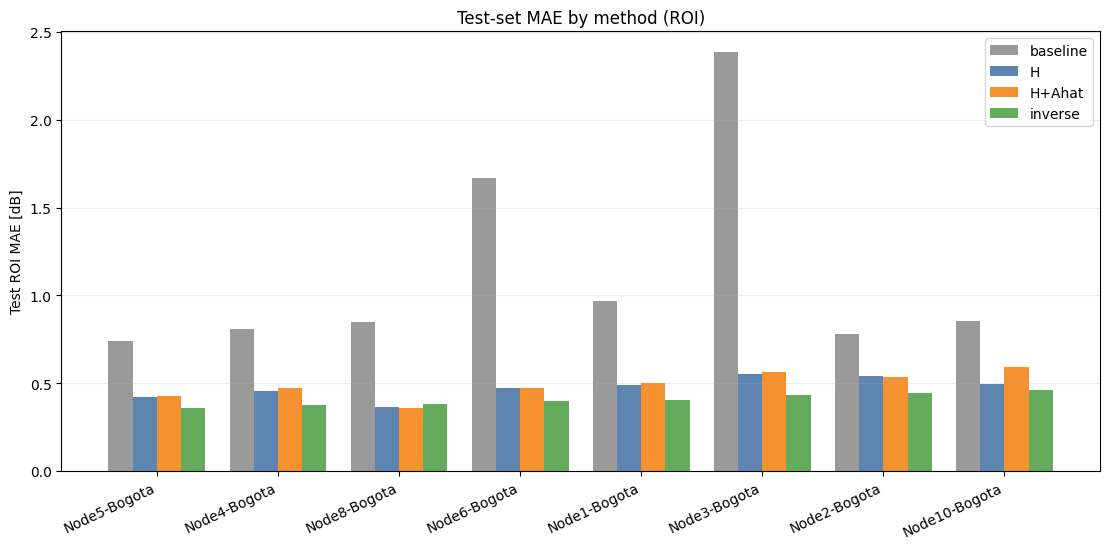

Saved row overlay diagnostics to: data/plots_inverse/inverse_row_overlay_diagnostics.png


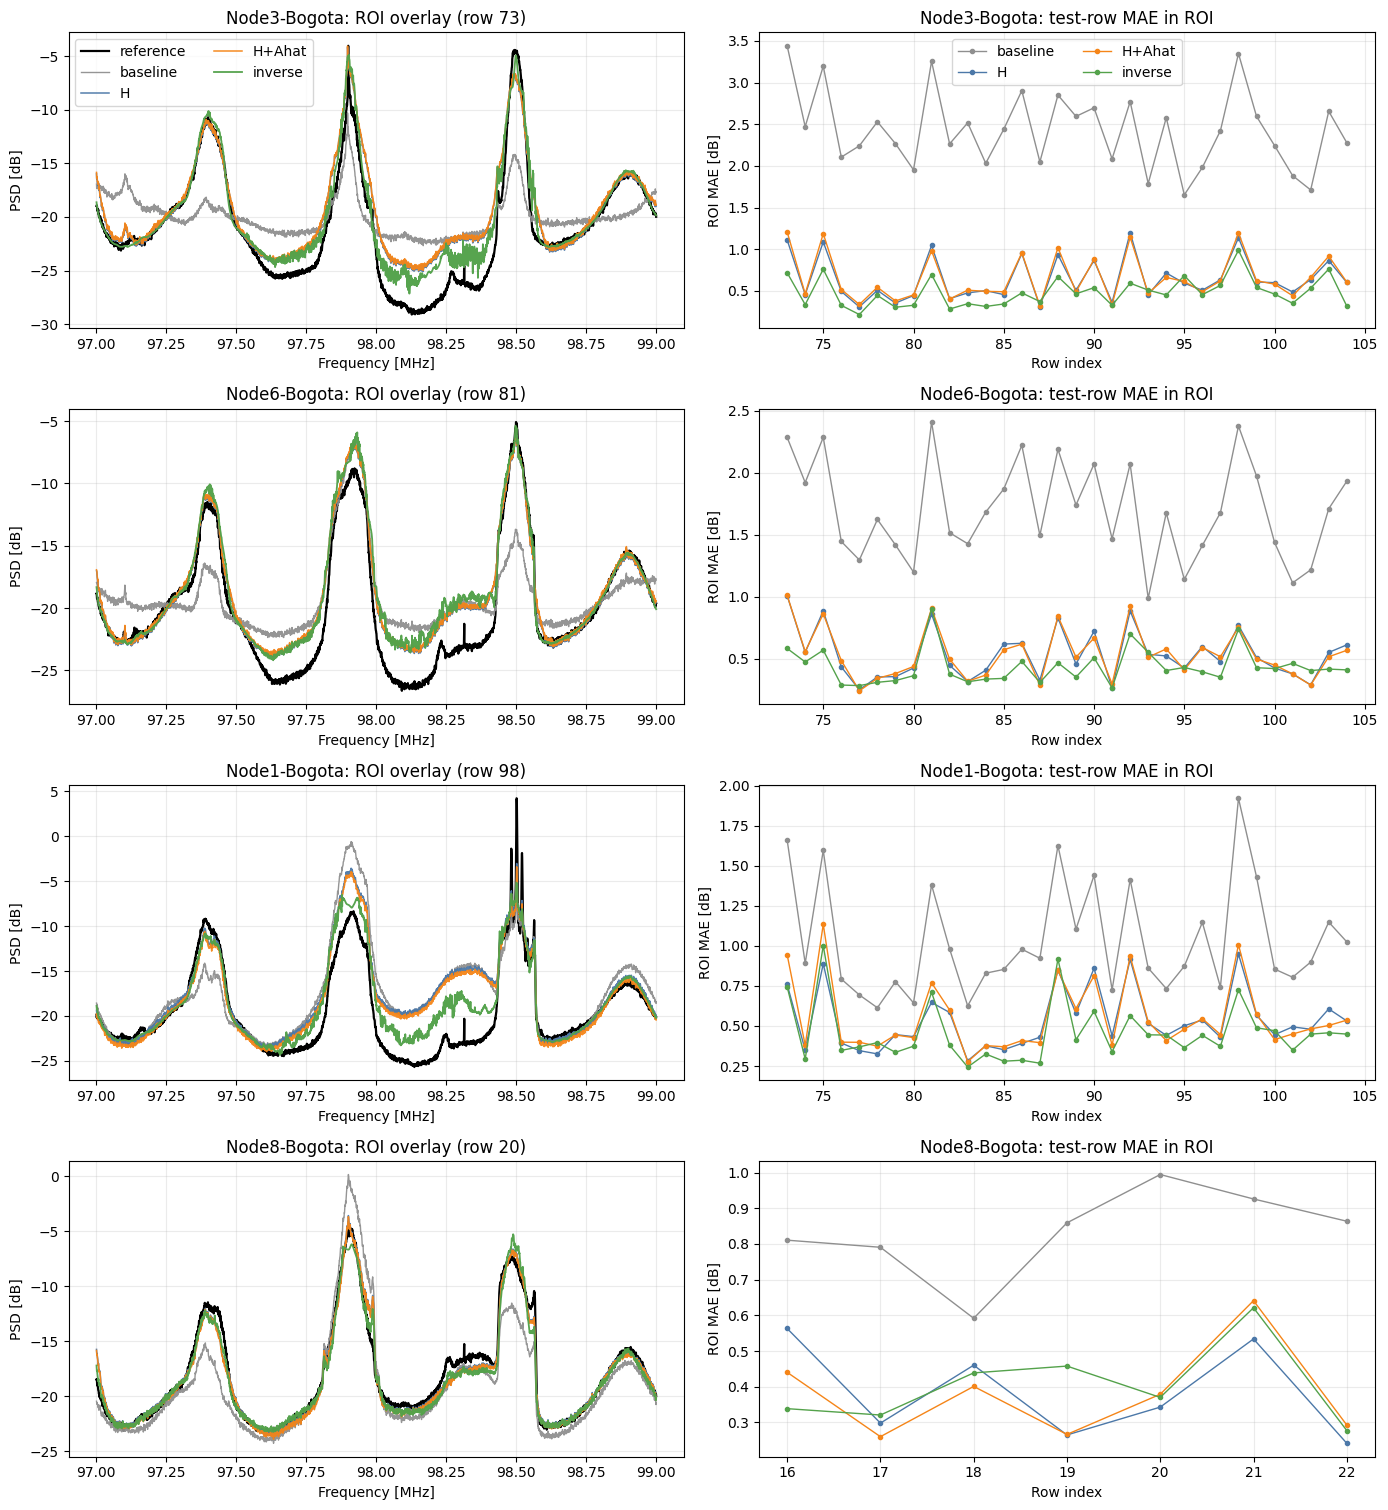

In [5]:
import matplotlib.pyplot as plt


def median_abs_error_by_row(
    P_est_db: np.ndarray,      # Estimated PSD matrix [rows, freq]
    P_ref_db: np.ndarray,      # Reference PSD matrix [rows, freq]
    roi_mask: np.ndarray,      # ROI mask over frequency [freq]
) -> np.ndarray:               # Per-row median absolute error in ROI [rows]
    '''Compute robust per-row ROI MAE between two aligned PSD matrices.

    Purpose:
    Provide a row-level error metric that is stable against outlier bins by
    using the median absolute residual in the selected ROI.

    Parameters:
    P_est_db: Estimated/calibrated PSD matrix in dB.
    P_ref_db: Reference PSD matrix in dB on the same axis.
    roi_mask: Boolean mask selecting ROI frequency bins.

    Returns:
    One MAE value per row in dB; NaN when a row has no finite ROI bins.

    Side effects:
    None.
    '''
    est = np.asarray(P_est_db, dtype=float)
    ref = np.asarray(P_ref_db, dtype=float)

    if est.shape != ref.shape:
        raise ValueError("P_est_db and P_ref_db must have the same shape")

    abs_err = np.abs(ref - est)[:, np.asarray(roi_mask, dtype=bool)]
    mae_row_db = np.full(abs_err.shape[0], np.nan, dtype=float)

    # Collapse ROI residuals into one robust scalar per row.
    for row_idx in range(abs_err.shape[0]):
        row_values = abs_err[row_idx]
        finite = row_values[np.isfinite(row_values)]
        if finite.size == 0:
            continue
        mae_row_db[row_idx] = float(np.median(finite))

    return mae_row_db


def plot_test_mae_bars(
    summary_df: pd.DataFrame,                  # Per-node MAE summary table
    output_path: Optional[Path] = None,        # Optional PNG output path
) -> None:                                     # Plot only
    '''Plot grouped test-set ROI MAE bars for all fitted nodes.

    Purpose:
    Compare baseline, linear H(f), H(f)+Ahat, and inverse mapping performance
    on the held-out test split in one compact figure.

    Parameters:
    summary_df: Per-node summary table produced by the run cell.
    output_path: Optional filesystem path to save the generated PNG.

    Returns:
    None.

    Side effects:
    Renders a Matplotlib figure and optionally writes an image to disk.
    '''
    fitted = summary_df.loc[summary_df["status"] == "fitted"].copy()
    if fitted.empty:
        print("No fitted nodes available for MAE bar diagnostics.")
        return

    method_cols = [
        "mae_test_baseline_db",
        "mae_test_H_db",
        "mae_test_H_plus_Ahat_db",
        "mae_test_inverse_db",
    ]
    method_labels = ["baseline", "H", "H+Ahat", "inverse"]
    method_colors = ["#8f8f8f", "#4c78a8", "#f58518", "#54a24b"]

    # Sort by inverse MAE to make relative gain visually obvious.
    fitted = fitted.sort_values(by="mae_test_inverse_db", ascending=True, kind="stable")
    x = np.arange(fitted.shape[0], dtype=float)
    bar_width = 0.20

    fig_w = max(10.0, 1.4 * fitted.shape[0])
    fig, ax = plt.subplots(figsize=(fig_w, 5.6))

    for idx, (col_name, label, color) in enumerate(zip(method_cols, method_labels, method_colors)):
        ax.bar(
            x + (idx - 1.5) * bar_width,
            fitted[col_name].to_numpy(dtype=float),
            width=bar_width,
            label=label,
            color=color,
            alpha=0.90,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(fitted["node"].tolist(), rotation=25, ha="right")
    ax.set_ylabel("Test ROI MAE [dB]")
    ax.set_title("Test-set MAE by method (ROI)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=140)
        print(f"Saved MAE bar plot to: {output_path}")

    plt.show()


def select_diagnostic_row(
    mae_baseline_row_db: np.ndarray,  # Per-row baseline MAE in ROI [rows]
    test_mask: np.ndarray,            # Test-row mask [rows]
) -> int:                             # Selected row index for PSD overlay
    '''Select a representative difficult test row for detailed overlay.

    Purpose:
    Pick the test row with the highest baseline ROI MAE so diagnostics focus
    on a challenging case for each node.

    Parameters:
    mae_baseline_row_db: Per-row baseline MAE values.
    test_mask: Boolean mask marking test rows.

    Returns:
    Selected row index, or -1 when no valid test rows are available.

    Side effects:
    None.
    '''
    baseline = np.asarray(mae_baseline_row_db, dtype=float).ravel()
    test = np.asarray(test_mask, dtype=bool).ravel()

    candidates = np.flatnonzero(test & np.isfinite(baseline))
    if candidates.size == 0:
        return -1

    local_idx = int(np.nanargmax(baseline[candidates]))
    return int(candidates[local_idx])


def plot_row_overlay_diagnostics(
    node_names: List[str],                         # Nodes to visualize
    model_by_node: Dict[str, Dict[str, Any]],     # Trained models per node
    data_by_node: Dict[str, pd.DataFrame],        # Raw node dataframes
    ref_df: pd.DataFrame,                         # Reference dataframe
    P_ref_full_db: np.ndarray,                    # Full reference PSD matrix [rows, freq]
    freq_ref_mhz: np.ndarray,                     # Reference frequency axis [freq]
    roi_mhz: Tuple[float, float] = ROI_MHZ,       # Overlay ROI [MHz]
    output_path: Optional[Path] = None,           # Optional PNG output path
) -> None:                                        # Plot only
    '''Plot row-level diagnostics: ROI overlays and test-row MAE trajectories.

    Purpose:
    Visualize how each calibration stage behaves on one difficult test row and
    how row-wise MAE evolves across the complete test segment.

    Parameters:
    node_names: Ordered list of nodes to include in the figure.
    model_by_node: In-memory trained model dictionary keyed by node.
    data_by_node: Raw node dataframes.
    ref_df: Raw reference dataframe.
    P_ref_full_db: Full reference PSD matrix aligned to `freq_ref_mhz`.
    freq_ref_mhz: Shared reference frequency axis in MHz.
    roi_mhz: Frequency interval emphasized in overlays.
    output_path: Optional filesystem path for PNG export.

    Returns:
    None.

    Side effects:
    Renders a Matplotlib figure and optionally writes an image to disk.
    '''
    _ = roi_mhz  # ROI is provided for explicit function contract and traceability.

    if not node_names:
        print("No nodes selected for row overlay diagnostics.")
        return

    n_rows_plot = len(node_names)
    fig, axes = plt.subplots(n_rows_plot, 2, figsize=(14.0, max(4.0, 3.8 * n_rows_plot)), squeeze=False)

    for row_plot_idx, node_name in enumerate(node_names):
        ax_curve = axes[row_plot_idx, 0]
        ax_mae = axes[row_plot_idx, 1]

        if node_name not in model_by_node:
            ax_curve.set_title(f"{node_name}: model unavailable")
            ax_curve.axis("off")
            ax_mae.axis("off")
            continue

        model = model_by_node[node_name]
        node_df = data_by_node[node_name]
        common_rows = int(min(len(node_df), len(ref_df)))

        P_ref_db = np.asarray(P_ref_full_db[:common_rows], dtype=float)
        P_i_db = build_node_matrix_on_reference(
            node_df=node_df,
            ref_freq_mhz=freq_ref_mhz,
            n_rows=common_rows,
            pxx_col=PXX_COLUMN,
        )

        H_db = np.asarray(model["H_db"], dtype=float)
        test_mask = np.asarray(model.get("test_mask", np.zeros(common_rows, dtype=bool)), dtype=bool)
        roi_mask = np.asarray(model["roi_mask"], dtype=bool)

        # Build all compared estimates using the same row set.
        P_h_db = P_i_db + H_db[None, :]
        A_hat_db, _, _ = estimate_offsets_from_state(model=model, P_i_db=P_i_db)
        P_ha_db = P_h_db + A_hat_db[:, None]
        P_inv_db, _, _, _ = apply_inverse_mapping_matrix(model=model, P_i_db=P_i_db)

        mae_baseline_row_db = median_abs_error_by_row(P_i_db, P_ref_db, roi_mask=roi_mask)
        mae_inverse_row_db = median_abs_error_by_row(P_inv_db, P_ref_db, roi_mask=roi_mask)
        mae_h_row_db = median_abs_error_by_row(P_h_db, P_ref_db, roi_mask=roi_mask)
        mae_ha_row_db = median_abs_error_by_row(P_ha_db, P_ref_db, roi_mask=roi_mask)

        diag_row_idx = select_diagnostic_row(mae_baseline_row_db=mae_baseline_row_db, test_mask=test_mask)
        if diag_row_idx < 0:
            ax_curve.set_title(f"{node_name}: no valid test rows")
            ax_curve.axis("off")
        else:
            roi_freq = np.asarray(freq_ref_mhz[roi_mask], dtype=float)

            # Overlay one difficult test row to inspect correction behavior in the ROI.
            ax_curve.plot(roi_freq, P_ref_db[diag_row_idx, roi_mask], color="black", lw=1.6, label="reference")
            ax_curve.plot(roi_freq, P_i_db[diag_row_idx, roi_mask], color="#8f8f8f", lw=1.0, alpha=0.95, label="baseline")
            ax_curve.plot(roi_freq, P_h_db[diag_row_idx, roi_mask], color="#4c78a8", lw=1.1, alpha=0.95, label="H")
            ax_curve.plot(roi_freq, P_ha_db[diag_row_idx, roi_mask], color="#f58518", lw=1.1, alpha=0.95, label="H+Ahat")
            ax_curve.plot(roi_freq, P_inv_db[diag_row_idx, roi_mask], color="#54a24b", lw=1.3, alpha=0.98, label="inverse")
            ax_curve.set_title(f"{node_name}: ROI overlay (row {diag_row_idx})")
            ax_curve.set_xlabel("Frequency [MHz]")
            ax_curve.set_ylabel("PSD [dB]")
            ax_curve.grid(alpha=0.25)
            if row_plot_idx == 0:
                ax_curve.legend(loc="best", ncols=2)

        # Plot row-wise test MAE to compare baseline and calibrated methods.
        test_rows = np.flatnonzero(test_mask)
        if test_rows.size == 0:
            ax_mae.set_title(f"{node_name}: no test rows")
            ax_mae.axis("off")
            continue

        x_test = test_rows.astype(float)
        ax_mae.plot(x_test, mae_baseline_row_db[test_rows], "o-", ms=3, lw=1.0, color="#8f8f8f", label="baseline")
        ax_mae.plot(x_test, mae_h_row_db[test_rows], "o-", ms=3, lw=1.0, color="#4c78a8", label="H")
        ax_mae.plot(x_test, mae_ha_row_db[test_rows], "o-", ms=3, lw=1.0, color="#f58518", label="H+Ahat")
        ax_mae.plot(x_test, mae_inverse_row_db[test_rows], "o-", ms=3, lw=1.0, color="#54a24b", label="inverse")
        ax_mae.set_title(f"{node_name}: test-row MAE in ROI")
        ax_mae.set_xlabel("Row index")
        ax_mae.set_ylabel("ROI MAE [dB]")
        ax_mae.grid(alpha=0.25)
        if row_plot_idx == 0:
            ax_mae.legend(loc="best", ncols=2)

    fig.tight_layout()

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=140)
        print(f"Saved row overlay diagnostics to: {output_path}")

    plt.show()


plots_dir = Path("data/plots_inverse")
plots_dir.mkdir(parents=True, exist_ok=True)

plot_test_mae_bars(
    summary_df=summary_df,
    output_path=plots_dir / "inverse_test_mae_bars.png",
)

fitted_for_diag = summary_df.loc[summary_df["status"] == "fitted"].copy()
if not fitted_for_diag.empty:
    fitted_for_diag["inverse_gain_db"] = (
        fitted_for_diag["mae_test_baseline_db"] - fitted_for_diag["mae_test_inverse_db"]
    )
    diag_nodes = (
        fitted_for_diag
        .sort_values(by="inverse_gain_db", ascending=False, kind="stable")
        ["node"]
        .head(4)
        .tolist()
    )
else:
    diag_nodes = []

plot_row_overlay_diagnostics(
    node_names=diag_nodes,
    model_by_node=model_by_node,
    data_by_node=data_by_node,
    ref_df=ref_df,
    P_ref_full_db=P_ref_full_db,
    freq_ref_mhz=freq_ref_mhz,
    roi_mhz=ROI_MHZ,
    output_path=plots_dir / "inverse_row_overlay_diagnostics.png",
)


## Notes and Limits

- This method can compensate monotone amplitude effects such as soft compression, gain-state bias, and raised floors.
- Without IQ, it cannot reconstruct non-invertible nonlinear artifacts (e.g., clipping/regrowth/intermodulation products).
- Layer A is critical: distorted rows are excluded from training so they do not bias the inverse model.
- Main tuning knobs: `LEVEL_BINS`, `INVERSE_FREQ_STRIDE`, `INVERSE_X_KNOTS`, `INVERSE_FREQ_SMOOTH_BINS`, and Layer-A threshold constants.
